In [9]:
from Analysis.systems import kitaev_chain,kramers_chain,kitaev_chain_spinful

import FockSystem.FockSystem as fst
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload
import time

In [10]:
from IPython.core.display import Markdown
from IPython.display import display

In [11]:
import Analysis.systems as kt

## Try Smarter memory

In [12]:
%load_ext cython 

The cython extension is already loaded. To reload it, use:
  %reload_ext cython


In [512]:
%%cython
import numpy as np
cimport numpy as cnp
from cython cimport boundscheck, wraparound
from cython.parallel import prange


@boundscheck(False)
@wraparound(False)
cdef int fill_memory(double[:] input_vec, double[:] output_vec,
                long start_i, long start_j, long small_rep, long big_rep, long big_rep_spacing, double val) nogil:
    cdef int i, j
    cdef long i_val, j_val
   
    for i in range(big_rep):
        for j in range(small_rep):
            i_val = start_i + i * big_rep_spacing + j
            j_val = start_j + i * big_rep_spacing + j
            output_vec[i_val] += input_vec[j_val] * val
            output_vec[j_val] += input_vec[i_val] * val
    return 0

# Parallel loop function in Cython using prange (OpenMP)
@boundscheck(False)
@wraparound(False)
cpdef matvec_fast(cnp.ndarray[double, ndim=1] input_vec, long long[:,:] H_base_data, cnp.ndarray[double, ndim=1] H_base_vals):
    cdef int counter=0
    cdef int n_tuples = H_base_data.shape[0]
    cdef cnp.ndarray[double,ndim=1] output_vec = np.zeros_like(input_vec,order='C')
    cdef long base_i, base_j, small_rep, big_rep, big_rep_spacing
    cdef double base_value = 0
    cdef int n_threads = 0

    for counter in range(n_tuples):
        base_i = H_base_data[counter][0]
        base_j = H_base_data[counter][1]
        small_rep = H_base_data[counter][2]
        big_rep = H_base_data[counter][3]
        big_rep_spacing = H_base_data[counter][4]
        base_value = H_base_vals[counter]
        if base_value != 0:
            fill_memory(input_vec,output_vec, base_i,base_j, small_rep,big_rep, big_rep_spacing,base_value)

    return output_vec




Error compiling Cython file:
------------------------------------------------------------
...
    cdef long thread_chunk_start =0
    cdef long thread_chunk_end = thread_data_size
    cdef int count_thread=0

    for count_thread in prange(n_threads,nogil=True):
        thread_data = H_base_data[count_thread]
        ^
------------------------------------------------------------

C:\Users\btenhaaf\.ipython\cython\_cython_magic_dce155c06e273b9c0249e2bb04af6a66fc1324e0.pyx:110:8: Memoryview slices can only be shared in parallel sections

Error compiling Cython file:
------------------------------------------------------------
...
    cdef long thread_chunk_end = thread_data_size
    cdef int count_thread=0

    for count_thread in prange(n_threads,nogil=True):
        thread_data = H_base_data[count_thread]
        thread_vals = H_base_vals[count_thread]
        ^
------------------------------------------------------------

C:\Users\btenhaaf\.ipython\cython\_cython_magic_dce155c06e273b

In [647]:
def add_conjugate_and_sort(sparse_matr, vals):
    only_indices = sparse_matr[:,:2]
    result_arr=[]
    result_vals=[]
    for enum,index_pair in enumerate(only_indices):
        if index_pair[0] == index_pair[1]:
            result_arr.append([index_pair[0],index_pair[1],index_pair[0],index_pair[1], 0,0, sparse_matr[enum][2],sparse_matr[enum][3],sparse_matr[enum][4]])
            result_vals.append(vals[enum]*2)
        else:
            result_arr.append([index_pair[0],index_pair[1],index_pair[0],index_pair[1], 0,0, sparse_matr[enum][2],sparse_matr[enum][3],sparse_matr[enum][4]])
            result_arr.append([index_pair[1],index_pair[0],index_pair[1],index_pair[0], 0,0, sparse_matr[enum][2],sparse_matr[enum][3],sparse_matr[enum][4]])
            result_vals.append(vals[enum])
            result_vals.append(vals[enum])

    result_arr=np.array(result_arr)
    result_vals = np.array(result_vals)
    sorted_indices = result_arr[:,0].argsort()
    sorted_arr = result_arr[sorted_indices]
    sorted_vals = result_vals[sorted_indices]
    
    return sorted_arr, sorted_vals

In [646]:
def get_parallel_heaps(sparse_format,sparse_values, N,n_threads=2):
    big_N = 4**N
    boundary = big_N//n_threads
    stacked_heaps = [[] for _ in range(n_threads)]
    stacked_vals = [[] for _ in range(n_threads)]

    count_stack = 0

    ## Initial pass to sort into correct list
    for data_row_idx in range(len(sparse_format)):
        start_row = sparse_format[data_row_idx][0]
        stacked_heaps[start_row//boundary].append(sparse_format[data_row_idx])
        stacked_vals[start_row//boundary].append(sparse_values[data_row_idx])


    final_heaps = deepcopy(stacked_heaps)
    final_vals = deepcopy(stacked_vals)
    ## Evolve all rows and add into the correct sublist
    for data_row_idx in range(n_threads):
        heap_data = stacked_heaps[data_row_idx]
        heap_vals = stacked_vals[data_row_idx]
       
        for idx in range(len(heap_data)):
            start_boundary = boundary*(data_row_idx+1)
            reached_bounds = False
            active_row = deepcopy(heap_data[idx])
            while(not reached_bounds):
                retrieve_next(active_row)
                if active_row[0]>=start_boundary and active_row[0]<big_N and active_row[1]<big_N:
                    final_heaps[active_row[0]//boundary].append(deepcopy(active_row))
                    final_vals[active_row[0]//boundary].append(heap_vals[idx])
                    start_boundary +=boundary
                elif active_row[0]>big_N or active_row[1]>big_N:
                    reached_bounds=True
    ## pad rows
    lengths = []
    for heaps in final_heaps:
        lengths.append(len(heaps))

    for idx in range(len(final_heaps)):
        dif = max(lengths) - lengths[idx]
        for _ in range(dif):
            final_heaps[idx].append([0,0,0,0,0,0,0,0,0])
            final_vals[idx].append(0)

    return np.array(final_heaps,dtype=np.int32),np.array(final_vals)

In [752]:
def retrieve_next(heap_list):
    ## Given a heap-row, progress it to its next value
    heap_list[0] = heap_list[2] + heap_list[4] + heap_list[5]*heap_list[8]
    heap_list[1] = heap_list[3] + heap_list[4] + heap_list[5]*heap_list[8]

    heap_list[4] += 1
    
    if heap_list[4] >= heap_list[6]:
        heap_list[4] = 0
        heap_list[5] += 1

## Threading

In [797]:
%%cython --compile-args=/openmp --link-args=/openmp
from cython.parallel import prange
import numpy as np
cimport numpy as cnp
from cython cimport boundscheck, wraparound

@boundscheck(False)
@wraparound(False)
cdef void fill_memory_cached(double[:] input_vec, double[:] output_vec,
                              long[:] data_row, double val,
                              long chunk_start, long chunk_end) noexcept nogil:
    cdef long i, j, i_val, j_val
    cdef long start_i = data_row[0]
    cdef long start_j = data_row[1]
    cdef long cur_i = data_row[4]
    cdef long cur_j = data_row[5]
    cdef long small_rep = data_row[6]
    cdef long big_rep = data_row[7]
    cdef long big_rep_spacing = data_row[8]

    for i in range(cur_i, big_rep):
        if i != cur_i:
            cur_j = 0
        for j in range(cur_j, small_rep):
            i_val = start_i + i * big_rep_spacing + j
            j_val = start_j + i * big_rep_spacing + j
            if i_val < chunk_start or i_val >= chunk_end:
                data_row[2] = i_val
                data_row[3] = j_val
                data_row[4] = i
                data_row[5] = j
                return
          
            output_vec[i_val] += input_vec[j_val] * val

    data_row[2] = i_val
    data_row[3] = j_val
    data_row[4] = big_rep
    data_row[5] = 0


@boundscheck(False)
@wraparound(False)
cdef void matvec_fast_cached(double[:] input_view, double[:] output_vec,
                              long[:,:,:]  thread_data,
                              double[:,:] thread_vals,
                              int thread_count,
                        
                              long chunk_size,
                              long thread_chunk_start,
                              long thread_chunk_end) noexcept nogil:

    cdef long chunk_start, chunk_end
    cdef long n_row_chunks = (thread_chunk_end - thread_chunk_start) // chunk_size
    cdef int counter_row_data, counter_chunks
    cdef double base_value
    cdef long[:] row_data
    
    for counter_chunks in range(n_row_chunks):
        chunk_start = chunk_size * counter_chunks + thread_chunk_start
        chunk_end = chunk_start + chunk_size
        
        for counter_row_data in range(thread_data[thread_count].shape[0]):
            base_value = thread_vals[thread_count][counter_row_data]
            if base_value != 0:
                row_data = thread_data[thread_count][counter_row_data]
                
                if row_data[4] < chunk_end:
                    fill_memory_cached(input_view, output_vec, row_data,
                                       base_value, chunk_start, chunk_end)


cpdef divide_and_conquer(cnp.ndarray[double, ndim=1] input_vec,
                         long[:,:,:] H_base_data,
                         double[:,:] H_base_vals,
                         long chunk_size,
                         int n_threads):

    cdef cnp.ndarray[double, ndim=1] output_vec = np.zeros_like(input_vec, order='C')
    cdef double[:] input_view = input_vec
    cdef double[:] output_view = output_vec

    cdef long thread_data_size = input_vec.shape[0] // n_threads

    cdef int count_thread
    cdef long thread_chunk_start, thread_chunk_end
    cdef long[:, :] thread_data
    cdef double[:] thread_vals
    
    for count_thread in prange(n_threads,nogil=True):
        
        thread_chunk_start = count_thread * thread_data_size
        thread_chunk_end = thread_chunk_start + thread_data_size
        matvec_fast_cached(input_view, output_view, H_base_data, H_base_vals,count_thread,
                           chunk_size, thread_chunk_start, thread_chunk_end)

    return output_vec

cdef extern from "omp.h":
    int omp_get_max_threads()
    int omp_get_num_threads()
    int omp_get_thread_num()

def check_available_threads():
    cdef int max_threads = omp_get_max_threads()
    print(f"Maximum OpenMP threads available: {max_threads}")

Content of stdout:
_cython_magic_c64cff4e4b3cc1c1e37383699be063bbdcf7f309.c
C:\Users\btenhaaf\AppData\Local\anaconda3\envs\KitaevTool\Lib\site-packages\numpy\_core\include\numpy\npy_1_7_deprecated_api.h(14) : Warning Msg: Using deprecated NumPy API, disable it with #define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION
C:\Users\btenhaaf\.ipython\cython\_cython_magic_c64cff4e4b3cc1c1e37383699be063bbdcf7f309.c(20404): warning C4244: '=': conversion from 'npy_intp' to 'long', possible loss of data
LINK : warning LNK4044: unrecognized option '/openmp'; ignored
   Creating library C:\Users\btenhaaf\.ipython\cython\Users\btenhaaf\.ipython\cython\_cython_magic_c64cff4e4b3cc1c1e37383699be063bbdcf7f309.cp312-win_amd64.lib and object C:\Users\btenhaaf\.ipython\cython\Users\btenhaaf\.ipython\cython\_cython_magic_c64cff4e4b3cc1c1e37383699be063bbdcf7f309.cp312-win_amd64.exp
Generating code
Finished generating code

In [798]:
check_available_threads()

Maximum OpenMP threads available: 4


In [812]:
N = 10
MU,U, ECT,CAR = kitaev_chain_spinful(N)
H = MU + CAR + ECT + U
H[MU] = 10
H[CAR] = 20
H[ECT] = -20
H[U] = 50
sparse_basis = fst.FockStatesSparse(N)

In [813]:
input_vector = np.array([np.random.randint(2) for _ in range(4**N)], dtype=np.float64)

sparse_format, sparse_values = add_conjugate_and_sort(H[sparse_basis].rc_indices,H[sparse_basis].values)
sparse_output = matvec_fast(input_vector, H[sparse_basis].rc_indices,H[sparse_basis].values)
n_threads = 4

In [816]:
chunk_size = 4**N/16
sparse_format, sparse_values = add_conjugate_and_sort(H[sparse_basis].rc_indices,H[sparse_basis].values)
final_heaps,final_vals = get_parallel_heaps(sparse_format,sparse_values, N, n_threads=n_threads)
#output = divide_and_conquer(input_vector, final_heaps,final_vals,chunk_size, n_threads=n_threads)

In [817]:
%time output = divide_and_conquer(input_vector, final_heaps,final_vals,chunk_size, n_threads=n_threads)

CPU times: total: 125 ms
Wall time: 83.8 ms


In [818]:
sparse_format, sparse_values = add_conjugate_and_sort(H[sparse_basis].rc_indices,H[sparse_basis].values)
%time sparse_output = matvec_fast(input_vector, H[sparse_basis].rc_indices,H[sparse_basis].values)


CPU times: total: 250 ms
Wall time: 230 ms


In [819]:
sparse_output

array([-200., -130., -150., ..., -100., -240., -200.], shape=(1048576,))

In [820]:
output


array([-200., -130., -150., ...,  -80., -220., -180.], shape=(1048576,))

In [788]:
np.allclose(sparse_output,output)

False

In [896]:
N_chunks = [1,2,4,16,32,64,128,256,512]
N = 10
MU,U, ECT,CAR = kitaev_chain_spinful(N)
H = MU + CAR + ECT + U
H[MU] = 10
H[CAR] = 20
H[ECT] = -20
H[U] = 50
sparse_basis = fst.FockStatesSparse(N)
H[sparse_basis]
cached_time = []

input_vector = np.array([np.random.randint(2) for _ in range(4**N)], dtype=np.float64)
start = time.perf_counter()
sparse_output = matvec_fast(input_vector, H[sparse_basis].rc_indices,H[sparse_basis].values)
end = time.perf_counter()
base_line_time = end-start

for n in N_chunks:
    print(n)
    MU,U, ECT,CAR = kitaev_chain_spinful(N)
    H = MU + CAR + ECT + U
    H[MU] = 10
    H[CAR] = 20
    H[ECT] = -20
    H[U] = 50
    sparse_basis = fst.FockStatesSparse(N)
    sparse_format, sparse_values = add_conjugate_and_sort(H[sparse_basis].rc_indices,H[sparse_basis].values)

    chunk_size = 4**N/n
    start = time.perf_counter()
    sparse_output_cache = matvec_fast_cached(input_vector, sparse_format,sparse_values, chunk_size)
    end = time.perf_counter()
    cached_time.append(end-start)


1
2
4
16
32
64
128
256
512


Text(0.5, 1.0, 'lowest 5 values (eigsh)')

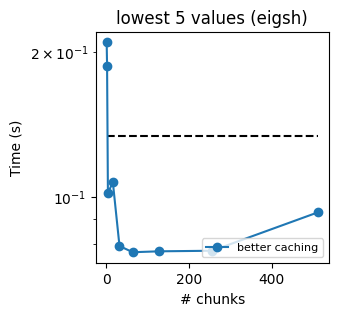

In [897]:
fig,axs = plt.subplots(ncols = 1, figsize=(3,3))

### Build Time
axs.set_yscale('log')

axs.plot([N_chunks[0],N_chunks[-1]], [base_line_time,base_line_time], linestyle='dashed', color='black' )

axs.plot(N_chunks, cached_time, label = 'better caching', marker='o')
axs.set_xlabel('# chunks')
axs.set_ylabel('Time (s)')
axs.legend(loc='lower right',ncols=1,fontsize=8)
axs.set_title('lowest 5 values (eigsh)')